# 2D Reaction-Diffusion Problem

This step-by-step tutorial goes over how to use the PRESSIO ROM tools and workflow scripts on the
[2D reaction diffusion PDE problem](https://pressio.github.io/pressio-demoapps/diffusion_reaction_2d.html) from pressio-demoapps.
The full example file is located at [https://github.com/Pressio/rom-tools-and-workflows](https://github.com/Pressio/rom-tools-and-workflows).

In [64]:
%matplotlib ipympl

# Pressio Modules
import pressiodemoapps as pda
import romtools as rt

# Python Modules
import os
import math
import json
import numpy as np
import matplotlib.pyplot as plt
import scipy

# Jupyter Modules
import ipywidgets as ipyw

In [ ]:
# Create initial input file


## Mesh Generation
Below is an example of generating the mesh for a range of x and y resolutions.

diffreac2d


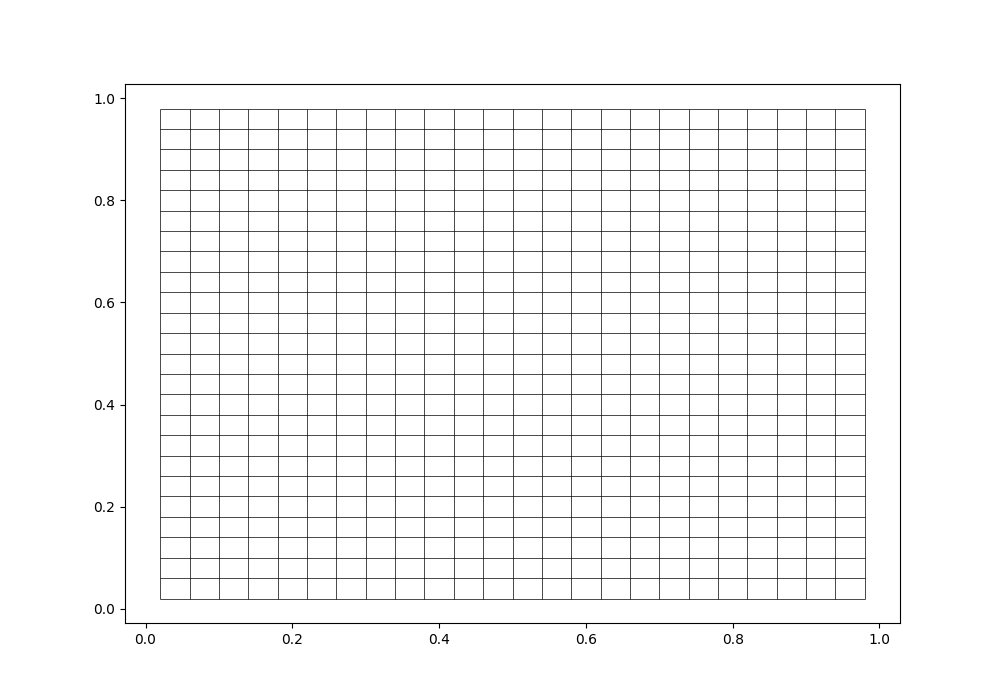

interactive(children=(IntSlider(value=27, description='n_x', max=50, min=5), IntSlider(value=27, description='…

In [65]:
def generate_mesh(pressio_file_path, mesh_path, figure_path, n_x, n_y):
    import os

    # generate mesh
    os.system('python3 ' + pressio_file_path + '/meshing_scripts/create_full_mesh_for.py --problem diffreac2d -n ' 
                + str(n_x) + ' ' + str(n_y) + ' --outdir ' + mesh_path)

    # load mesh
    mesh_obj = pda.load_cellcentered_uniform_mesh(mesh_path)

    # plot mesh
    x = mesh_obj.viewX()
    y = mesh_obj.viewY()
    unique_x = list(set(x))
    unique_y = list(set(y))
    ax.cla()
    for i in range(0,len(unique_x)):
        ax.vlines(unique_x[i], np.max(unique_y), np.min(unique_y), colors = 'k', linewidth = 0.5)
    for i in range(0,len(unique_y)):
        ax.hlines(unique_y[i], np.min(unique_x), np.max(unique_x), colors = 'k', linewidth = 0.5)

    return mesh_obj

# Define paths
pressio_file_path = 'my_pressio_file_path'
mesh_path = 'my_mesh_path'
figure_path = 'my_figure_path'

pressio_file_path = '/Users/ekrath/codes/pressio/pressio-demoapps'
mesh_path = '/Users/ekrath/codes/pressio/mywork/demo-apps/2d-reaction-diffusion/mesh'
figure_path = 'figs'

# Generate and plot mesh
fig = plt.figure(figsize=(10,7))
ax = plt.gca()
mesh_obj = generate_mesh(pressio_file_path=pressio_file_path, mesh_path=mesh_path, figure_path=figure_path, n_x=25, n_y=25)
plt.show()

# NOTE: This is specific to the jupyter notebook only.
# Interactable widget for changes in x and y mesh resolution.
def update(n_x, n_y):
    mesh_obj = generate_mesh(pressio_file_path=pressio_file_path, mesh_path=mesh_path, figure_path=figure_path, n_x=n_x, n_y=n_y)
    fig.canvas.draw()
    return mesh_obj
f = ipyw.interactive(update, n_x=(5,50,1), n_y=(5,50,1))

# Display the interactive widget
display(f)


In [66]:
# Get the value of mesh_obj from f
mesh_obj = f.result

## Full-Order Model
This section will go over how to setup and run the full-order model (FOM).

First, we define our FOM Model class. It is important to note that this class follows the [QoiModel](http://localhost:8080/romtools/workflows/models.html#QoiModel.__init__) class, which is required for greedy sampling.

In [63]:
class FOM_Model(rt.workflows.models.QoiModel):
    def __init__(self):
        return None

    def populate_run_directory(self, run_directory, parameter_sample):
        os.system('cp input.json ' + run_directory + '/.')
        return 0

    def run_model(self, run_directory, parameter_sample):
        # Swap to run directory
        cdir = os.getcwd()
        os.chdir(run_directory)

        # Open and Read Input File
        f = open(file_name)
        input = json.load(f)
        f.close()

        # Parse Input File
        mesh_path = input['mesh_path']
        # dt = input['dt']
        # n_steps = input['n_steps']

        # Load mesh
        mesh_obj = pda.load_cellcentered_uniform_mesh(mesh_path)

        # Define Scheme
        # A. set scheme
        scheme  = pda.ViscousFluxReconstruction.FirstOrder

        # B. constructor for problem using default values
        prob_ID  = pda.DiffusionReaction2d.ProblemA
        self._problem = pda.create_problem(mesh_obj, prob_ID, scheme)

        # C. setting custom coefficients and custom source function
        self._problem = pda.create_diffusion_reaction_2d_problem_A(mesh_obj, scheme, my_source, parameter_sample['D'], parameter_sample['K'])

        # (For Unsteady ROM)
        # Run FOM
        # # A. get initial condition
        # yn = problem.initialCondition()

        # # B. solve
        # max_y = []
        # for i in range(0, n_steps):
        #     pda.advanceRK4(problem, yn, dt, 1) #n_steps)
        #     max_y.append(np.max(yn))

        # C. Plot convergence
        # plt.figure(figsize=(10,7))
        # plt.plot(max_y)
        # plt.savefig('y_convergence.jpeg')
        # plt.close()
        
        # (For Steady ROM)
        # D. Define residual function
        F = self._problem.createRightHandSide()
        def residual(x):
            self._problem.rightHandSide(x,0.,F)
            return F
        
        # Solve FOM
        yn = scipy.optimize.newton_krylov(residual, self._problem.initialCondition(), verbose=False)

        # Save solution
        np.savez('results.npz', y=yn, parameters=[parameter_sample['D'], parameter_sample['K']])

        # Swap back to base directory
        os.chdir(cdir)

        return 0 # NOTE: This function must return 0

    def compute_qoi(self, run_directory, parameter_sample):
        return np.load(run_directory + '/results.npz')['y']

# Define FOM
fom_model = FOM_Model()